Phase 5.1 — DeepFM sanity check with default config (`emb_dim=8`, `dropout=0.2`, `l2=1e-4`, `lr=1e-3`, 10 epochs). Goal is to confirm the DeepFM architecture trains end-to-end and clears the FM baseline from Phase 4 before launching the multi-stage hyperparameter sweep.

> **Note on feature version**: this notebook trains on the **v1** item features (9 fields, no text embedding). The **v2** sentence-transformer item text embedding (`item_text_emb_pca32`, ColBERT-light) was introduced later as a Phase 3 augmentation (see `docs/training_pipeline_plan.md` §3.2.4). It first enters training at **05c** (dropout × L2 grid). 5.1 is kept on v1 because its only purpose is to sanity-check the DeepFM forward / backward / eval pipeline and confirm a beat over the FM baseline — the architectural correctness check is independent of which item features are present.

In [1]:
import json
import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import platform

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s",
                    datefmt="%H:%M:%S", force=True)
log = logging.getLogger(__name__)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"
FEATURES_DIR = PROJECT_ROOT / "data" / "features"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"arch: {platform.machine()}")
print(f"torch: {torch.__version__}")
print(f"device: {DEVICE}")

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


arch: arm64
torch: 2.11.0
device: mps


**Inline copies of the data loaders + eval helpers from Phase 4** (notebook is self-contained, doesn't import from `src/`).

In [2]:
class IDEncoder:
    def __init__(self, ids, oov_token="<UNK>"):
        oov_markers = {"<NEW_USER>", "<NEW_BUSINESS>", "<UNK>", oov_token}
        unique_real_ids = sorted({i for i in ids if i not in oov_markers})
        self.id_to_idx = {oov_token: 0}
        for idx, _id in enumerate(unique_real_ids, start=1):
            self.id_to_idx[_id] = idx
        for marker in oov_markers:
            self.id_to_idx.setdefault(marker, 0)
        self._size = 1 + len(unique_real_ids)

    def __len__(self):
        return self._size

    def encode(self, _id):
        return self.id_to_idx.get(_id, 0)

    def encode_array(self, ids):
        return ids.map(self.id_to_idx).fillna(0).astype(np.int64).values


class TasteHunterDataset(Dataset):
    def __init__(self, df, user_encoder, item_encoder, user_features, item_features):
        self.user_idx = torch.from_numpy(user_encoder.encode_array(df["user_id"]))
        self.item_idx = torch.from_numpy(item_encoder.encode_array(df["business_id"]))
        self.label = torch.from_numpy(df["label"].astype(np.float32).values)
        n_users = len(user_encoder)
        n_items = len(item_encoder)
        self.user_num = np.zeros((n_users, 6), dtype=np.float32)
        self.user_cuisine = np.zeros((n_users, 50), dtype=np.float32)
        for _, row in user_features.iterrows():
            uidx = user_encoder.encode(row["user_id"])
            self.user_num[uidx] = [row["avg_rating_given"], row["review_count_log"], row["days_active"],
                                    row["elite_flag"], row["mean_distance_traveled"], row["price_tolerance_avg"]]
            emb = row["fav_cuisine_emb"]
            if isinstance(emb, list) and len(emb) == 50:
                self.user_cuisine[uidx] = emb
        self.item_num = np.zeros((n_items, 7), dtype=np.float32)
        self.item_cat = np.zeros((n_items, 50), dtype=np.float32)
        for _, row in item_features.iterrows():
            iidx = item_encoder.encode(row["business_id"])
            self.item_num[iidx] = [row["avg_rating"], row["review_count_log"], row["price_level"],
                                    row["is_open"], row["has_outdoor_seating"], row["photo_count_log"], row["city_id"]]
            cat = row["categories_multi_hot"]
            if isinstance(cat, list) and len(cat) == 50:
                self.item_cat[iidx] = cat
        self.user_num_t = torch.from_numpy(self.user_num)
        self.user_cuisine_t = torch.from_numpy(self.user_cuisine)
        self.item_num_t = torch.from_numpy(self.item_num)
        self.item_cat_t = torch.from_numpy(self.item_cat)

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        u = self.user_idx[idx]
        i = self.item_idx[idx]
        return {
            "user_idx": u, "item_idx": i, "label": self.label[idx],
            "user_num": self.user_num_t[u], "user_cuisine": self.user_cuisine_t[u],
            "item_num": self.item_num_t[i], "item_cat": self.item_cat_t[i],
        }


def make_val_eval_pairs(val_df, user_encoder, item_encoder, item_features, n_negs=99, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    val_pos = val_df[val_df["stars"] >= 4].copy()
    biz_city = item_features.set_index("business_id")["city"].to_dict()
    val_pos["city"] = val_pos["business_id"].map(biz_city).fillna("<UNK>")
    city_biz = {}
    for bid, c in biz_city.items():
        if c == "<UNK>":
            continue
        city_biz.setdefault(c, []).append(bid)
    for c in city_biz:
        city_biz[c] = np.array(city_biz[c])
    all_user, all_item, all_label = [], [], []
    for row in val_pos.itertuples(index=False):
        if row.city not in city_biz:
            continue
        candidates = city_biz[row.city]
        sampled = rng.choice(candidates, size=n_negs * 2, replace=True)
        negs = [b for b in sampled if b != row.business_id][:n_negs]
        if len(negs) < n_negs:
            continue
        items = [row.business_id] + negs
        all_user.append([user_encoder.encode(row.user_id)] * (n_negs + 1))
        all_item.append([item_encoder.encode(b) for b in items])
        all_label.append([1.0] + [0.0] * n_negs)
    return (np.array(all_user, dtype=np.int64),
            np.array(all_item, dtype=np.int64),
            np.array(all_label, dtype=np.float32))


def compute_auc(scores, labels):
    pos_mask = labels > 0.5
    n_pos = pos_mask.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    order = np.argsort(scores)
    ranks = np.empty(len(scores))
    ranks[order] = np.arange(1, len(scores) + 1)
    return float((ranks[pos_mask].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def ndcg_at_k(score_matrix, label_matrix, k=10):
    top_k_idx = np.argsort(-score_matrix, axis=1)[:, :k]
    rows = np.arange(score_matrix.shape[0])[:, None]
    top_k_labels = label_matrix[rows, top_k_idx]
    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    dcg = (top_k_labels * discounts).sum(axis=1)
    ideal_labels = -np.sort(-label_matrix, axis=1)[:, :k]
    idcg = (ideal_labels * discounts).sum(axis=1)
    idcg = np.where(idcg > 0, idcg, 1.0)
    return float(np.mean(dcg / idcg))


def recall_at_k(score_matrix, label_matrix, k=10):
    top_k_idx = np.argsort(-score_matrix, axis=1)[:, :k]
    rows = np.arange(score_matrix.shape[0])[:, None]
    top_k_labels = label_matrix[rows, top_k_idx]
    n_pos_per_row = label_matrix.sum(axis=1)
    correct = top_k_labels.sum(axis=1)
    return float(np.mean(np.where(n_pos_per_row > 0, correct / n_pos_per_row, 0)))


@torch.no_grad()
def score_pairs(model, user_idx, item_idx, dataset, device, batch_size=8192):
    model.eval()
    n, c = user_idx.shape
    flat_u = user_idx.reshape(-1)
    flat_i = item_idx.reshape(-1)
    scores = np.zeros(n * c, dtype=np.float32)
    for start in range(0, len(flat_u), batch_size):
        end = min(start + batch_size, len(flat_u))
        u_b = torch.from_numpy(flat_u[start:end]).to(device)
        i_b = torch.from_numpy(flat_i[start:end]).to(device)
        u_t = torch.from_numpy(flat_u[start:end])
        i_t = torch.from_numpy(flat_i[start:end])
        kwargs = {
            "user_num": dataset.user_num_t[u_t].to(device),
            "user_cuisine": dataset.user_cuisine_t[u_t].to(device),
            "item_num": dataset.item_num_t[i_t].to(device),
            "item_cat": dataset.item_cat_t[i_t].to(device),
        }
        s = model(u_b, i_b, **kwargs).cpu().numpy().reshape(-1)
        scores[start:end] = s
    return scores.reshape(n, c)


def evaluate_full(model, user_idx_eval, item_idx_eval, label_eval, dataset, device):
    score_matrix = score_pairs(model, user_idx_eval, item_idx_eval, dataset, device)
    return {
        "AUC": compute_auc(score_matrix.reshape(-1), label_eval.reshape(-1)),
        "NDCG@10": ndcg_at_k(score_matrix, label_eval, k=10),
        "Recall@10": recall_at_k(score_matrix, label_eval, k=10),
    }

**DeepFM model.** FM 2nd-order over 4 fields (user_emb, item_emb, user_num projected to emb_dim, item_num projected to emb_dim) using the efficient form `0.5 * [(Σx)^2 - Σx^2]`. DNN branch concatenates all 4 emb fields plus the two multi-hot vectors and runs through MLP[256, 128, 64]. FM and DNN share the same embedding tables — that's the key DeepFM design choice (Guo et al. 2017): the embedding gets gradient from both heads at once, so it learns representations that work for both pairwise interactions and high-order DNN combinations, and parameter count stays half of running them separately.

In [3]:
class DeepFM(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=8,
                 user_num_dim=6, user_cuisine_dim=50,
                 item_num_dim=7, item_cat_dim=50,
                 dnn_hidden=(256, 128, 64), dropout=0.2,
                 ablate_user_id=False):
        super().__init__()
        self.emb_dim = emb_dim
        self.ablate_user_id = ablate_user_id

        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.user_num_proj = nn.Linear(user_num_dim, emb_dim)
        self.item_num_proj = nn.Linear(item_num_dim, emb_dim)

        feat_dim_linear = user_num_dim + item_num_dim + user_cuisine_dim + item_cat_dim
        self.linear_features = nn.Linear(feat_dim_linear, 1)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        dnn_input_dim = emb_dim * 4 + user_cuisine_dim + item_cat_dim
        layers = []
        prev = dnn_input_dim
        for h in dnn_hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.dnn = nn.Sequential(*layers)

        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user_idx, item_idx, user_num, user_cuisine, item_num, item_cat):
        u_emb = self.user_emb(user_idx)
        i_emb = self.item_emb(item_idx)
        un_emb = self.user_num_proj(user_num)
        in_emb = self.item_num_proj(item_num)

        if self.ablate_user_id:
            u_emb = torch.zeros_like(u_emb)

        feat_concat = torch.cat([user_num, item_num, user_cuisine, item_cat], dim=-1)
        order1 = self.linear_features(feat_concat).squeeze(-1)
        bu = self.user_bias(user_idx).squeeze(-1)
        bi = self.item_bias(item_idx).squeeze(-1)
        if self.ablate_user_id:
            bu = torch.zeros_like(bu)

        embs = torch.stack([u_emb, i_emb, un_emb, in_emb], dim=1)
        sum_sq = embs.sum(dim=1) ** 2
        sq_sum = (embs ** 2).sum(dim=1)
        order2 = 0.5 * (sum_sq - sq_sum).sum(dim=-1)

        dnn_input = torch.cat([u_emb, i_emb, un_emb, in_emb, user_cuisine, item_cat], dim=-1)
        dnn_output = self.dnn(dnn_input).squeeze(-1)

        return torch.sigmoid(order1 + order2 + dnn_output + bu + bi + self.global_bias)

Load features + build encoders + dataset + val eval pairs.

In [4]:
user_features = pd.read_parquet(FEATURES_DIR / "user_features.parquet")
item_features = pd.read_parquet(FEATURES_DIR / "item_features.parquet")
val_df = pd.read_parquet(CLEANED_DIR / "val_reviews.parquet")
train_df = pd.read_parquet(FEATURES_DIR / "train_with_negatives.parquet")

user_encoder = IDEncoder(user_features["user_id"].tolist(), oov_token="<NEW_USER>")
item_encoder = IDEncoder(item_features["business_id"].tolist(), oov_token="<NEW_BUSINESS>")
n_users, n_items = len(user_encoder), len(item_encoder)
print(f"encoders: {n_users} users, {n_items} items")

user_idx_eval, item_idx_eval, label_eval = make_val_eval_pairs(
    val_df, user_encoder, item_encoder, item_features, n_negs=99,
)
print(f"val eval: {user_idx_eval.shape[0]} users x {user_idx_eval.shape[1]} candidates")

t0 = time.time()
train_ds = TasteHunterDataset(train_df, user_encoder, item_encoder, user_features, item_features)
print(f"train dataset built in {time.time()-t0:.1f}s ({len(train_ds)} samples)")
train_loader = DataLoader(train_ds, batch_size=8192, shuffle=True, num_workers=0, pin_memory=True)

encoders: 359008 users, 9023 items
val eval: 60482 users x 100 candidates


/var/folders/dt/jg5mtn_s7tq8ffsylm1vfnxm0000gn/T/ipykernel_95730/3837305626.py:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.user_idx = torch.from_numpy(user_encoder.encode_array(df["user_id"]))


train dataset built in 7.2s (2075285 samples)


Train one DeepFM with the sanity config and evaluate every epoch.

In [5]:
CONFIG = {"emb_dim": 8, "dropout": 0.2, "l2": 1e-4, "lr": 1e-3, "epochs": 10}
print(f"config: {CONFIG}")

model = DeepFM(n_users, n_items, emb_dim=CONFIG["emb_dim"], dropout=CONFIG["dropout"]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["l2"])
bce = nn.BCELoss()

history = {"epoch": [], "train_loss": [], "val_auc": [], "val_ndcg10": [], "val_recall10": []}

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    loss_sum, n_batch = 0.0, 0
    t0 = time.time()
    for batch in train_loader:
        u = batch["user_idx"].to(DEVICE)
        i = batch["item_idx"].to(DEVICE)
        y = batch["label"].to(DEVICE)
        kwargs = {k: batch[k].to(DEVICE) for k in ("user_num", "user_cuisine", "item_num", "item_cat")}
        pred = model(u, i, **kwargs)
        loss = bce(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        n_batch += 1
    train_loss = loss_sum / n_batch
    elapsed = time.time() - t0

    metrics = evaluate_full(model, user_idx_eval, item_idx_eval, label_eval, train_ds, DEVICE)
    print(f"epoch {epoch:02d} | {elapsed:.0f}s | loss={train_loss:.4f} | AUC={metrics['AUC']:.4f} NDCG@10={metrics['NDCG@10']:.4f} Recall@10={metrics['Recall@10']:.4f}")
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_auc"].append(metrics["AUC"])
    history["val_ndcg10"].append(metrics["NDCG@10"])
    history["val_recall10"].append(metrics["Recall@10"])

torch.save(model.state_dict(), MODELS_DIR / "deepfm_emb8_drop0.2_l21e-4_sanity.pt")
history["config"] = CONFIG
history["best_ndcg10"] = max(history["val_ndcg10"])
with open(MODELS_DIR / "deepfm_emb8_drop0.2_l21e-4_sanity_history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"\nbest NDCG@10: {history['best_ndcg10']:.4f}")

config: {'emb_dim': 8, 'dropout': 0.2, 'l2': 0.0001, 'lr': 0.001, 'epochs': 10}


/Users/yanghaobo/miniforge3/envs/yelp-arm64/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


epoch 01 | 40s | loss=0.4041 | AUC=0.8075 NDCG@10=0.2641 Recall@10=0.4636
epoch 02 | 36s | loss=0.3197 | AUC=0.8035 NDCG@10=0.2675 Recall@10=0.4669
epoch 03 | 41s | loss=0.3112 | AUC=0.8092 NDCG@10=0.2749 Recall@10=0.4794
epoch 04 | 39s | loss=0.2974 | AUC=0.8156 NDCG@10=0.2979 Recall@10=0.5130
epoch 05 | 37s | loss=0.2811 | AUC=0.8240 NDCG@10=0.3121 Recall@10=0.5306
epoch 06 | 39s | loss=0.2659 | AUC=0.8299 NDCG@10=0.3173 Recall@10=0.5360
epoch 07 | 36s | loss=0.2525 | AUC=0.8314 NDCG@10=0.3201 Recall@10=0.5398
epoch 08 | 36s | loss=0.2407 | AUC=0.8270 NDCG@10=0.3126 Recall@10=0.5305
epoch 09 | 39s | loss=0.2292 | AUC=0.8310 NDCG@10=0.3180 Recall@10=0.5375
epoch 10 | 39s | loss=0.2193 | AUC=0.8339 NDCG@10=0.3191 Recall@10=0.5397

best NDCG@10: 0.3201


Plot training curves to visually confirm the model is learning (loss decreasing, val metrics rising).

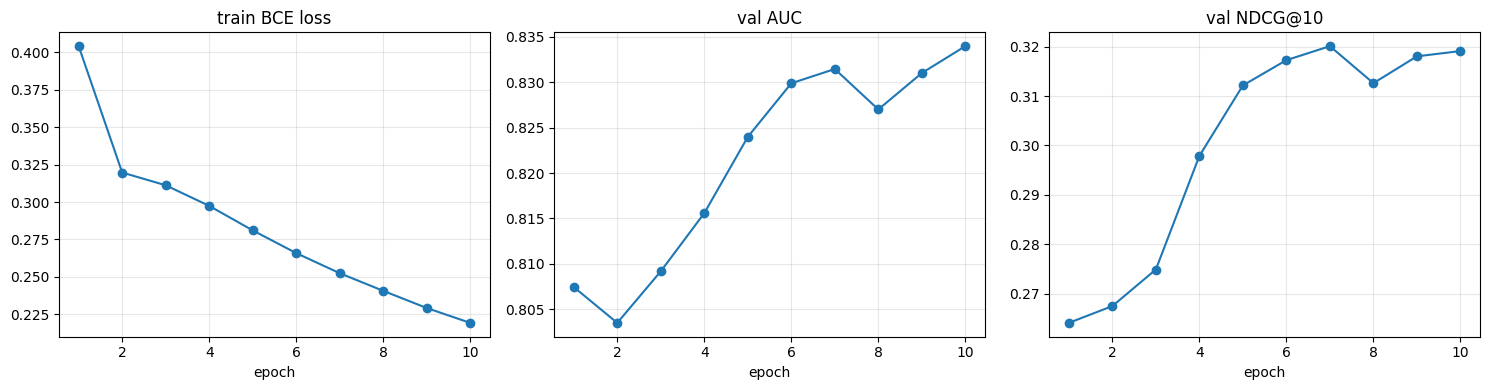

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["epoch"], history["train_loss"], "o-")
axes[0].set_title("train BCE loss")
axes[1].plot(history["epoch"], history["val_auc"], "o-")
axes[1].set_title("val AUC")
axes[2].plot(history["epoch"], history["val_ndcg10"], "o-")
axes[2].set_title("val NDCG@10")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_deepfm_sanity.png", bbox_inches="tight")
plt.show()

DeepFM with the default config should clear the FM baseline (val AUC ~0.83, NDCG@10 ~0.27 from Phase 4) — the gain comes from the FM 2nd-order pairwise term and the DNN's ability to capture higher-order feature interactions on top of the same shared embedding. Phase 5.2 then sweeps `emb_dim` to find the right capacity, Phase 5.3 grids dropout × L2 for regularization, Phase 5.4 retrains on train+val merged with the final config, and Phase 5.5 ablates user_id embedding to verify hypothesis H6.